In [40]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-data/heart_disease_uci.csv


In [41]:
# استيراد المكتبات الضرورية
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report  ,confusion_matrix , accuracy_score

In [42]:
# 1. تحميل البيانات
data = pd.read_csv('/kaggle/input/heart-disease-data/heart_disease_uci.csv')

In [43]:
# 2. استكشاف البيانات
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None


In [44]:
print(data.describe())

               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  268.000000  157.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

               ca         num  
count  309.000000  920.000000  
mean     0.676375    0.995652  
std      0.935653    1.142693  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      0.000000    1.000000  
75%      1.000000    2.000000  
max      3.000

In [45]:
print(data.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [46]:
#check the shape of dataset
print(data.shape)

(920, 16)


In [47]:
#smmary statistics of 'age' variable
data['age'].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

In [48]:
#minimum and maximum age for heart disease 
print("The minimum age for heart disease diagnosis is: ",data['age'].min())
print("The maximum age for heart disease diagnosis is: ",data['age'].max())

The minimum age for heart disease diagnosis is:  28
The maximum age for heart disease diagnosis is:  77


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0, 'Age')

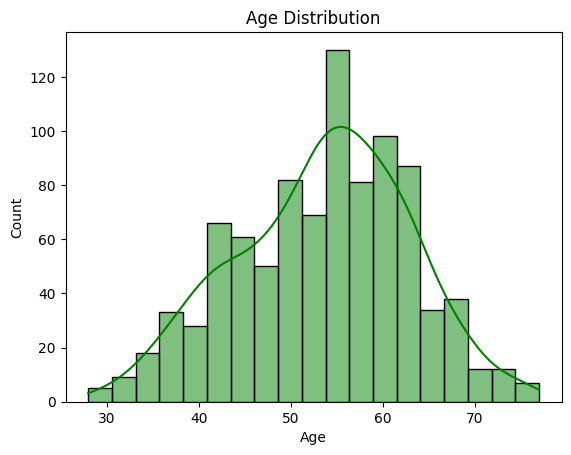

In [49]:
#plot distribution of age column
sns.histplot(data=data, x='age', kde=True,color='green')
plt.title('Age Distribution')
plt.xlabel('Age')

In [50]:
print(data['restecg'].value_counts())
print(data['exang'].value_counts())
print(data['slope'].value_counts())
print(data['num'].value_counts())


restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64
exang
False    528
True     337
Name: count, dtype: int64
slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [51]:
#lets check the value count of sex variable in this data
data['sex'].value_counts()


sex
Male      726
Female    194
Name: count, dtype: int64

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


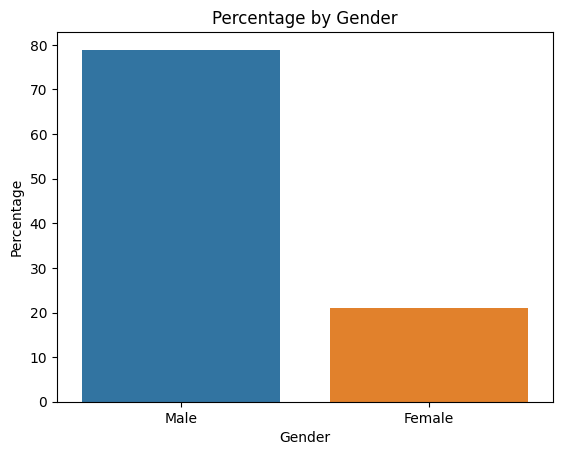

In [52]:
#plot percentages through barplot
sns.barplot(x=['Male', 'Female'], y=[male_percentage, female_percentage])
plt.title('Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.show()

In [53]:
print(data['dataset'].value_counts())

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64


<Axes: xlabel='dataset', ylabel='count'>

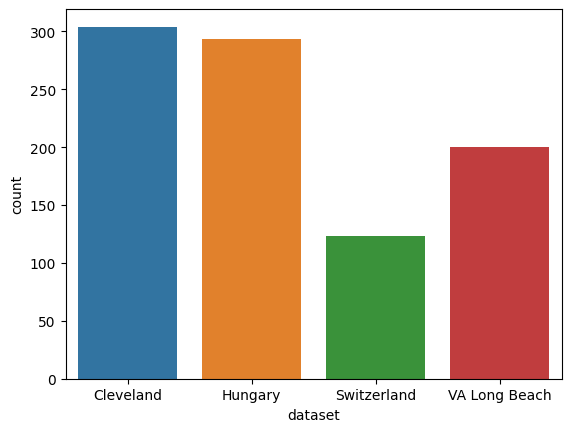

In [54]:
#plot the countplot of dataset variable
sns.countplot(data=data,x='dataset')

In [55]:
# 3. معالجة القيم المفقودة


data['trestbps'] = data['trestbps'].fillna(data['trestbps'].mean())
data['chol'] = data['chol'].fillna(data['chol'].mean())
data['fbs'] = data['fbs'].fillna(data['fbs'].mode()[0])
data['restecg'] = data['restecg'].fillna(data['restecg'].mode()[0])
data['thalch'] = data['thalch'].fillna(data['thalch'].mean())
data['exang'] = data['exang'].fillna(data['exang'].mode()[0])
data['oldpeak'] = data['oldpeak'].fillna(data['oldpeak'].mean())
data['slope'] = data['slope'].fillna(data['slope'].mode()[0])
data['ca'] = data['ca'].fillna(data['ca'].mean())
data['thal'] = data['thal'].fillna(data['thal'].mode()[0])

# 2. التحقق من البيانات بعد المعالجة
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    bool   
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    bool   
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    object 
 13  ca        920 non-null    float64
 14  thal      920 non-null    object 
 15  num       920 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(6)
memory usage: 102.5+ KB
None
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical a

/tmp/ipykernel_24/3698039337.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['fbs'] = data['fbs'].fillna(data['fbs'].mode()[0])
/tmp/ipykernel_24/3698039337.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['exang'] = data['exang'].fillna(data['exang'].mode()[0])


In [56]:


# إنشاء كائن من LabelEncoder
label_encoder = LabelEncoder()

# تحويل الأعمدة الفئوية باستخدام Label Encoding
data['sex'] = label_encoder.fit_transform(data['sex'])  # تحويل الجنس
data['fbs'] = label_encoder.fit_transform(data['fbs'])  # تحويل سكر الدم
data['exang'] = label_encoder.fit_transform(data['exang'])  # تحويل الألم أثناء الجهد

# تحويل الأعمدة التي تحتوي على قيم فئوية متعددة
data['dataset'] = label_encoder.fit_transform(data['dataset'])
data['cp'] = label_encoder.fit_transform(data['cp'])
data['restecg'] = label_encoder.fit_transform(data['restecg'])
data['slope'] = label_encoder.fit_transform(data['slope'])
data['thal'] = label_encoder.fit_transform(data['thal'])

# التحقق من البيانات بعد التحويل
print(data.head())
print(data.info())

   id  age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   1   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   2   67    1        0   0     160.0  286.0    0        0   108.0      1   
2   3   67    1        0   0     120.0  229.0    0        0   129.0      1   
3   4   37    1        0   2     130.0  250.0    0        1   187.0      0   
4   5   41    0        0   1     130.0  204.0    0        0   172.0      0   

   oldpeak  slope   ca  thal  num  
0      2.3      0  0.0     0    0  
1      1.5      1  3.0     1    2  
2      2.6      1  2.0     2    1  
3      3.5      0  0.0     1    0  
4      1.4      2  0.0     1    0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    int64  
 3   dataset   

In [57]:
# 5. تقييس الميزات العددية
scaler = StandardScaler()
numerical_features = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
data[numerical_features] = scaler.fit_transform(data[numerical_features])

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


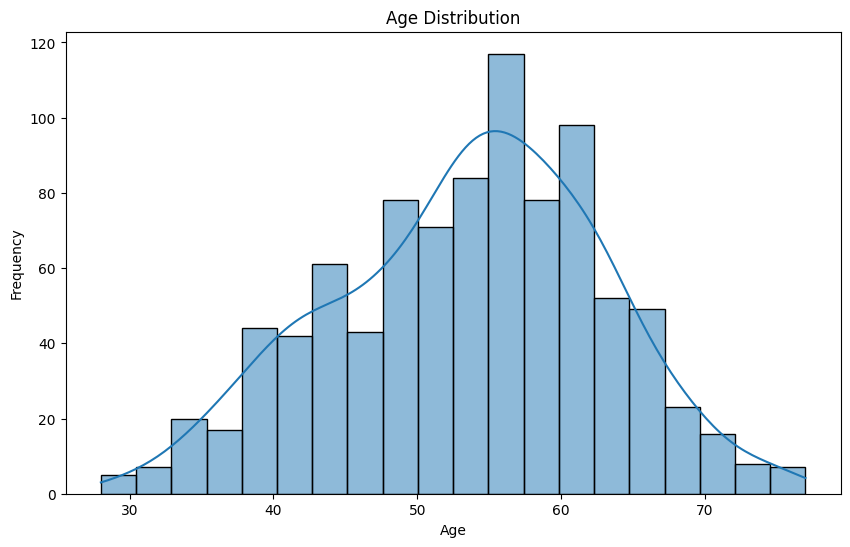

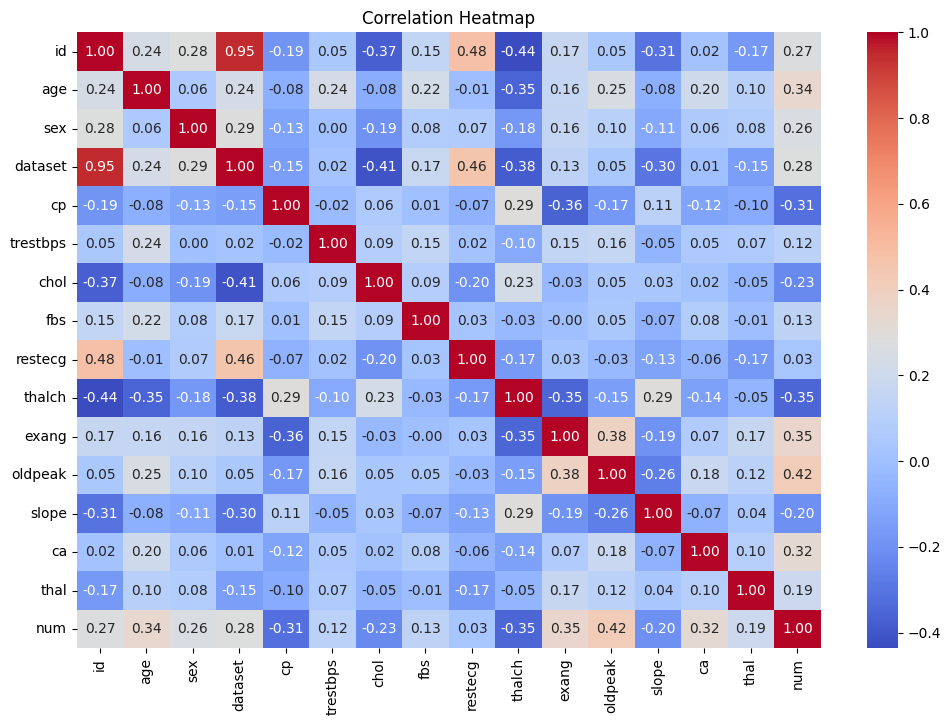

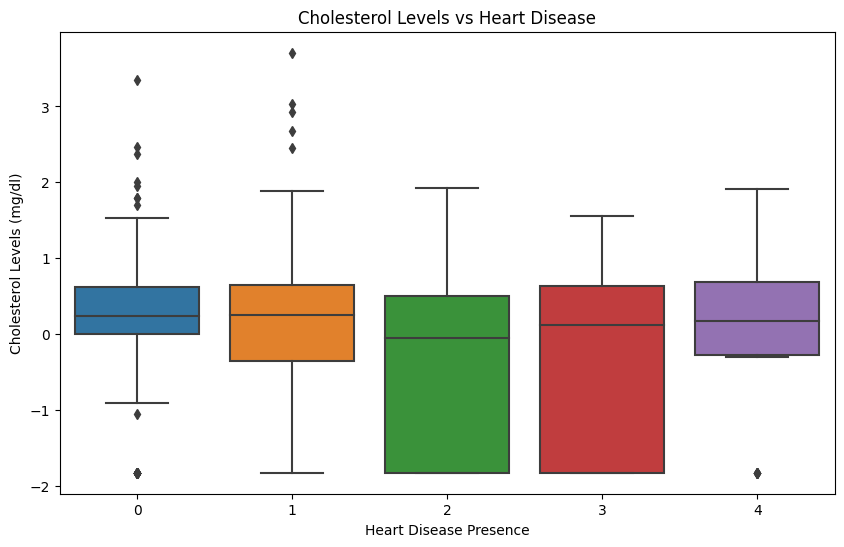

In [66]:
# Histogram of age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Boxplot for cholesterol levels by heart disease presence
plt.figure(figsize=(10, 6))
sns.boxplot(x='num', y='chol', data=data)
plt.title('Cholesterol Levels vs Heart Disease')
plt.xlabel('Heart Disease Presence')
plt.ylabel('Cholesterol Levels (mg/dl)')
plt.show()

In [58]:
# 6. تقسيم البيانات إلى مجموعة تدريب واختبار
# X = data.drop(['id', 'num'], axis=1)  # الميزات
# y = data['num'] 
X = data.drop(columns='id', axis=1)  # الميزات
y = data['num']  # المتغير المستهدف
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
# 7. تطبيق خوارزميات التعلم الآلي
# نموذج شجرة القرار
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [60]:
# نموذج k-NN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [61]:
# نموذج Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [62]:
# 8. تقييم الأداء
# توقعات نموذج شجرة القرار
dt_predictions = dt_model.predict(X_test)

# توقعات نموذج k-NN
knn_predictions = knn_model.predict(X_test)

# توقعات نموذج Random Forest
rf_predictions = rf_model.predict(X_test)

In [63]:
# طباعة تقارير الأداء
print("Decision Tree Classification Report:\n", classification_report(y_test, dt_predictions))
print("k-NN Classification Report:\n", classification_report(y_test, knn_predictions))
print("Random Forest Classification Report:\n", classification_report(y_test, rf_predictions)) 

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        54
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00         4

    accuracy                           1.00       184
   macro avg       1.00      1.00      1.00       184
weighted avg       1.00      1.00      1.00       184

k-NN Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.92      0.84        75
           1       0.48      0.54      0.51        54
           2       0.33      0.24      0.28        25
           3       0.79      0.42      0.55        26
           4       0.50      0.25      0.33         4

    accuracy                           0.63       184
   macro avg       0.57      0.47      0.50       184
weighted a

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


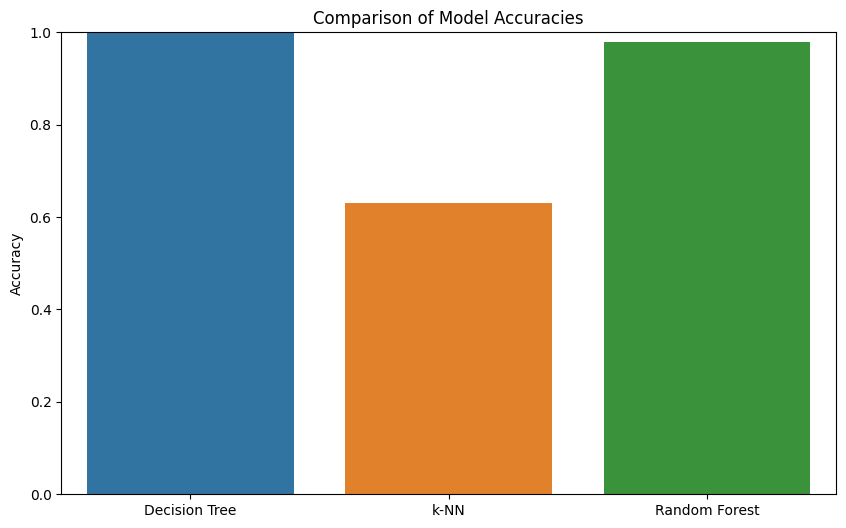

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


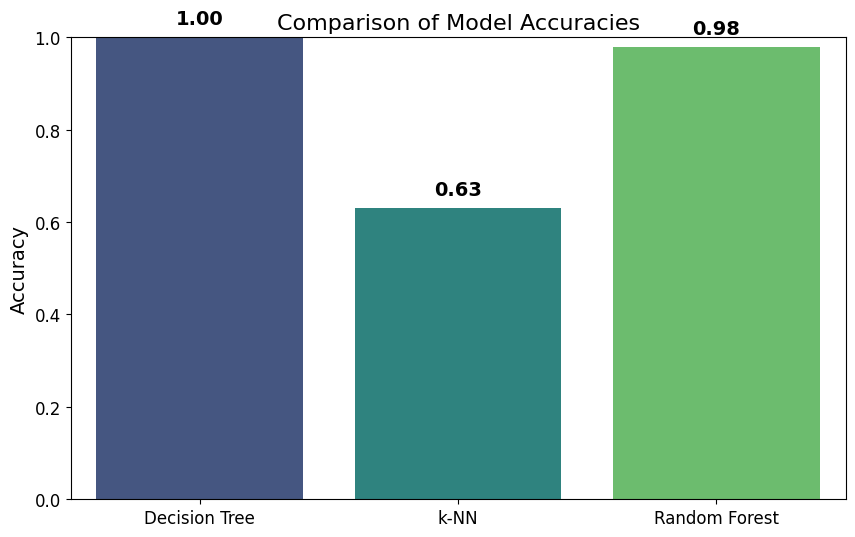

In [69]:
# 10. مقارنة الأداء
model_names = ['Decision Tree', 'k-NN', 'Random Forest']
accuracies = [
    accuracy_score(y_test, dt_predictions),
    accuracy_score(y_test, knn_predictions),
    accuracy_score(y_test, rf_predictions)
]

# رسم مقارنة الدقة
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies)
plt.title('Comparison of Model Accuracies')  # تغيير العنوان إلى الإنجليزية
plt.ylabel('Accuracy')  # تغيير التسمية إلى الإنجليزية
plt.ylim(0, 1)  # تعيين نطاق المحور Y من 0 إلى 1
plt.show()


# رسم مقارنة الدقة
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x=model_names, y=accuracies, palette='viridis')

# إضافة القيم فوق الأعمدة بشكل أوضح
for index, value in enumerate(accuracies):
    bar_plot.text(index, value + 0.02,  # إضافة مسافة فوق العمود
                  f"{value:.2f}", 
                  ha='center', 
                  va='bottom', 
                  fontsize=14,  # حجم الخط
                  color='black',  # لون النص
                  fontweight='bold')  # سمك الخط

plt.title('Comparison of Model Accuracies', fontsize=16)  # حجم خط العنوان
plt.ylabel('Accuracy', fontsize=14)  # حجم خط التسمية
plt.ylim(0, 1)  # تعيين نطاق المحور Y من 0 إلى 1
plt.xticks(fontsize=12)  # حجم خط تسميات المحاور السينية
plt.yticks(fontsize=12)  # حجم خط تسميات المحاور الصادية
plt.show()

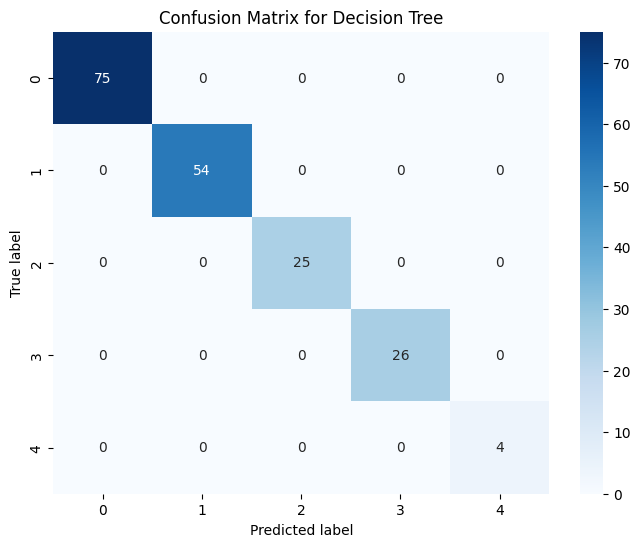

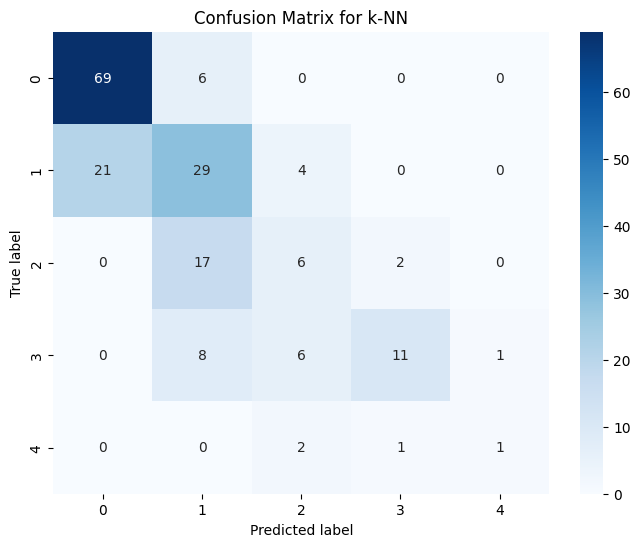

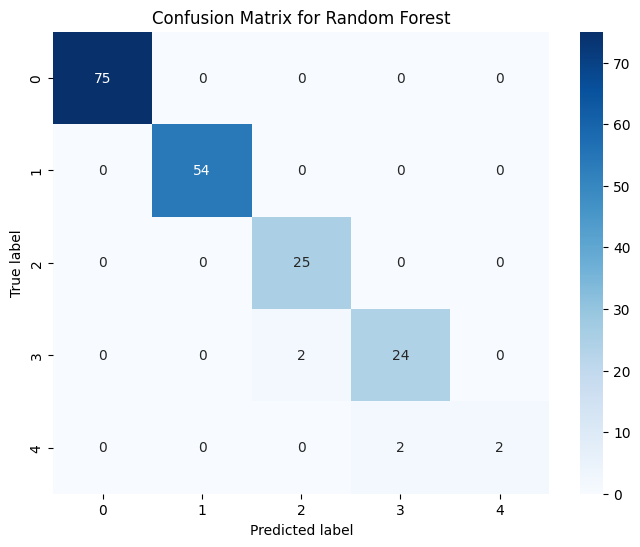

In [73]:
# حساب مصفوفة الالتباس للنموذج
dt_confusion = confusion_matrix(y_test, dt_predictions)
knn_confusion = confusion_matrix(y_test, knn_predictions)
rf_confusion = confusion_matrix(y_test, rf_predictions)

# رسم مصفوفة الالتباس لـ Decision Tree
plt.figure(figsize=(8, 6))
sns.heatmap(dt_confusion, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# رسم مصفوفة الالتباس لـ k-NN
plt.figure(figsize=(8, 6))
sns.heatmap(knn_confusion, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix for k-NN')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# رسم مصفوفة الالتباس لـ Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(rf_confusion, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()